In [1]:
import pandas as pd
import numpy as np

In [2]:
india_df = pd.read_csv("alternative_credit_scoring.csv")
sri_df = pd.read_csv("sri lankan .csv")

print("India dataset:", india_df.shape)
print("Sri Lankan dataset:", sri_df.shape)

print(india_df.columns)
print(sri_df.columns)

India dataset: (2000, 29)
Sri Lankan dataset: (344, 22)
Index(['age', 'monthly_income_inr', 'area_type', 'upi_monthly_avg_txn_count',
       'upi_avg_txn_amount', 'upi_failed_txn_ratio',
       'mobile_recharge_consistency_score', 'mobile_recharge_lapse_days_max',
       'utility_bills_on_time_pct', 'electricity_bill_avg_amount',
       'cooperative_meeting_attendance_pct', 'shg_savings_amount_inr',
       'microfinance_loans_repaid_count', 'microfinance_default_rate',
       'gig_monthly_earnings', 'gig_platform_rating', 'jandhan_avg_balance',
       'jandhan_zero_balance_months', 'monthly_data_usage_gb',
       'telecom_bill_late_payments', 'banking_app_login_frequency_monthly',
       'fintech_apps_count', 'rent_on_time_payment_pct',
       'rent_to_income_ratio', 'social_referral_count',
       'insurance_policy_count', 'alternative_credit_score',
       'credit_risk_label', 'loan_approved'],
      dtype='object')
Index(['Membership ID', 'Loan Number ', 'group no', 'share amt', 'Lo

In [3]:

def clean_money(value):
    value = str(value)
    value = value.replace("LKR", "")
    value = value.replace(",", "")
    value = value.replace("%", "")
    value = value.strip().lower()

    invalid_values = ["", "nan", "no", "none", "inactive", "active", "-"]

    if value in invalid_values:
        return 0.0

    try:
        return float(value)
    except ValueError:
        return 0.0


def yes_no_to_number(value):
    value = str(value).strip().lower()

    if value in ["yes", "y", "1", "true", "ok", "approved"]:
        return 1
    return 0


def count_guarantors(row):
    guarantor_cols = ["Gurantor 1", "Gurantor 2", "Gurantor 3", "Gurantor 4"]
    count = 0

    for col in guarantor_cols:
        if col in row.index:
            value = str(row[col]).strip().lower()
            if value not in ["", "nan", "no", "none", "inactive", "-"]:
                count += 1

    return count

In [4]:

india_df = india_df.rename(columns={
    "monthly_income_inr": "monthly_income",
    "gig_monthly_earnings": "other_income",
    "jandhan_avg_balance": "savings_balance",
    "credit_risk_label": "risk_level"
})

np.random.seed(42)

india_df["expenses"] = (
    india_df["monthly_income"] * np.random.uniform(0.3, 0.8, len(india_df))
).round(2)

india_df["loan_amount"] = (
    india_df["monthly_income"] * np.random.uniform(2, 6, len(india_df))
).round(2)

india_df["loan_type"] = np.where(
    india_df["loan_amount"] <= 25000,
    "Below_25000",
    "Above_25000"
)

india_df["existing_loans"] = np.random.randint(0, 4, len(india_df))

india_df["repayment_history"] = np.where(
    india_df["microfinance_loans_repaid_count"] > 0,
    1,
    0
)

india_df["guarantor_support_count"] = np.random.randint(2, 5, len(india_df))

india_df.head()

,age,monthly_income,area_type,upi_monthly_avg_txn_count,upi_avg_txn_amount,upi_failed_txn_ratio,mobile_recharge_consistency_score,mobile_recharge_lapse_days_max,utility_bills_on_time_pct,electricity_bill_avg_amount,...,insurance_policy_count,alternative_credit_score,risk_level,loan_approved,expenses,loan_amount,loan_type,existing_loans,repayment_history,guarantor_support_count
0,56,28426,Rural,57,1207.68,0.024,0.98,75,0.75,2265.13,...,0,680,Low Risk,1,13851.14,86608.98,Above_25000,1,1,4
1,46,20772,Semi-Urban,113,1194.25,0.067,0.38,30,0.56,2471.31,...,1,519,High Risk,0,16105.72,62064.97,Above_25000,0,1,4
2,32,8450,Rural,40,373.44,0.041,0.64,11,0.48,2168.64,...,1,696,Low Risk,1,5627.67,47531.40,Above_25000,3,1,4
3,60,6712,Urban,5,85.96,0.220,0.16,56,0.60,1412.54,...,3,563,Medium Risk,0,4022.70,20123.82,Below_25000,0,1,3
4,25,4367,Urban,74,127.76,0.347,0.98,65,0.92,1815.76,...,3,677,Low Risk,1,1650.77,13484.42,Below_25000,2,1,4


# Prepare Sri Lankan dataset

In [5]:
sri_df = sri_df.rename(columns={
    "share amt": "share_amount",
    "Loan Type": "loan_type",
    "Amount": "loan_amount",
    "saving balance": "savings_balance",
    "existing loans": "existing_loans",
    "Monthly income": "monthly_income",
    "other income": "other_income",
    "expences": "expenses"
})

money_cols = [
    "share_amount",
    "loan_amount",
    "savings_balance",
    "monthly_income",
    "other_income",
    "expenses"
]

for col in money_cols:
    if col in sri_df.columns:
        sri_df[col] = sri_df[col].apply(clean_money)

if "existing_loans" in sri_df.columns:
    sri_df["existing_loans"] = sri_df["existing_loans"].apply(yes_no_to_number)
else:
    sri_df["existing_loans"] = 0

sri_df["repayment_history"] = 1

sri_df["guarantor_support_count"] = sri_df.apply(count_guarantors, axis=1)

sri_df.head()

,Membership ID,Loan Number,group no,share_amount,loan_type,Loan Date,Reason For Loan,loan_amount,Rate,months of installements,...,other_income,expenses,Gurantor 1,Gurantor 2,Gurantor 3,Gurantor 4,reapyment status,status,repayment_history,guarantor_support_count
0,1/4061,12181,no,100.0,long term,20/03/2022,house repairing,250000.0,17%,60.0,...,6000.0,12500.0,ok,ok,no,no,yes,approved,1,2
1,1/3572,6003-2121-12142,no,100.0,long term,06/03/2024,To buy electric items,250000.0,14%,60.0,...,0.0,0.0,ok,ok,no,no,yes,approved,1,2
2,1/1734,6003-2121-12153,no,100.0,long term,10/03/2024,To buy household items,250000.0,23%,60.0,...,1666.6,20000.0,ok,ok,no,no,yes,approved,1,2
3,1/3573,12197,no,100.0,long term,11/03/2024,To buy household items,250000.0,23%,60.0,...,0.0,20000.0,ok,ok,no,no,yes,approved,1,2
4,1/4022,12159,no,100.0,long term,14/03/2024,To buy computer,250000.0,23%,60.0,...,0.0,50000.0,ok,ok,no,no,yes,approved,1,2


In [6]:
'''
def create_sri_risk(row):

    total_income = (
        row["monthly_income"]
        + row["other_income"]
    )

    expenses = row["expenses"]

    loan_amount = row["loan_amount"]

    savings = row["savings_balance"]

    existing_loans = row["existing_loans"]

    guarantors = row["guarantor_support_count"]

    repayment_status = str(
        row["reapyment status"]
    ).strip().lower()

    disposable_income = total_income - expenses

    loan_to_income_ratio = (
        loan_amount / total_income
        if total_income > 0 else 999
    )

    savings_ratio = (
        savings / total_income
        if total_income > 0 else 0
    )

    if repayment_status in [
        "no",
        "default",
        "unpaid",
        "inactive"
    ]:
        return "High Risk"

    elif (
        loan_to_income_ratio <= 2
        and disposable_income > 20000
        and savings_ratio > 0.3
        and existing_loans == 0
        and guarantors >= 2
        and repayment_status in [
            "yes",
            "paid",
            "completed",
            "settled"
        ]
    ):
        return "Low Risk"

    elif (
        loan_to_income_ratio <= 5
        and disposable_income > 5000
        and guarantors >= 2
    ):
        return "Medium Risk"

    else:
        return "High Risk"


sri_df["risk_level"] = sri_df.apply(
    create_sri_risk,
    axis=1
)

print(sri_df["risk_level"].value_counts())
'''

'\ndef create_sri_risk(row):\n\n    total_income = (\n        row["monthly_income"]\n        + row["other_income"]\n    )\n\n    expenses = row["expenses"]\n\n    loan_amount = row["loan_amount"]\n\n    savings = row["savings_balance"]\n\n    existing_loans = row["existing_loans"]\n\n    guarantors = row["guarantor_support_count"]\n\n    repayment_status = str(\n        row["reapyment status"]\n    ).strip().lower()\n\n    disposable_income = total_income - expenses\n\n    loan_to_income_ratio = (\n        loan_amount / total_income\n        if total_income > 0 else 999\n    )\n\n    savings_ratio = (\n        savings / total_income\n        if total_income > 0 else 0\n    )\n\n    if repayment_status in [\n        "no",\n        "default",\n        "unpaid",\n        "inactive"\n    ]:\n        return "High Risk"\n\n    elif (\n        loan_to_income_ratio <= 2\n        and disposable_income > 20000\n        and savings_ratio > 0.3\n        and existing_loans == 0\n        and guarant

In [7]:
final_columns = [
    "monthly_income",
    "other_income",
    "expenses",
    "loan_amount",
    "loan_type",
    "savings_balance",
    "existing_loans",
    "repayment_history",
    "guarantor_support_count",
    
]

india_final = india_df[final_columns]
sri_final = sri_df[final_columns]

print(india_final.head())
print(sri_final.head())

   monthly_income  other_income  expenses  loan_amount    loan_type  \
0           28426          0.00  13851.14     86608.98  Above_25000   
1           20772          0.00  16105.72     62064.97  Above_25000   
2            8450      10521.48   5627.67     47531.40  Above_25000   
3            6712      19200.47   4022.70     20123.82  Below_25000   
4            4367      22173.61   1650.77     13484.42  Below_25000   

   savings_balance  existing_loans  repayment_history  guarantor_support_count  
0             0.00               1                  1                        4  
1             0.00               0                  1                        4  
2           207.58               3                  1                        4  
3          1024.81               0                  1                        3  
4          1730.63               2                  1                        4  
   monthly_income  other_income  expenses  loan_amount  loan_type  \
0        49962.25 

# Combine datasets

In [8]:
'''combined_df = pd.concat([india_final, sri_final], ignore_index=True)'''
import os

# Check if your new data file exists
if os.path.exists("new_low_risk_data.csv"):
    new_low_risk_df = pd.read_csv("new_low_risk_data.csv")
    # Combine all 3 datasets
    combined_df = pd.concat([india_final, sri_final, new_low_risk_df], ignore_index=True)
else:
    # Fallback to the original 2 datasets if the file isn't found
    combined_df = pd.concat([india_final, sri_final], ignore_index=True)

print(combined_df.shape)
print(combined_df.head())
#print(combined_df["risk_level"].value_counts())

# Total income
combined_df["total_income"] = (
    combined_df["monthly_income"] + combined_df["other_income"]
)

# Disposable income
combined_df["disposable_income"] = (
    combined_df["total_income"] - combined_df["expenses"]
)

# Disposable income ratio
combined_df["disposable_income_ratio"] = combined_df.apply(
    lambda row: row["disposable_income"] / row["total_income"]
    if row["total_income"] > 0 else 0,
    axis=1
)

# Loan to income ratio
combined_df["loan_to_income_ratio"] = combined_df.apply(
    lambda row: row["loan_amount"] / row["total_income"]
    if row["total_income"] > 0 else 999,
    axis=1
)

# Savings to income ratio
combined_df["savings_to_income_ratio"] = combined_df.apply(
    lambda row: row["savings_balance"] / row["total_income"]
    if row["total_income"] > 0 else 0,
    axis=1
)

# Guarantor acceptance flag
combined_df["guarantor_requirement_met"] = combined_df["guarantor_support_count"].apply(
    lambda x: 1 if x >= 2 else 0
)

print(combined_df.head())

(2354, 9)
   monthly_income  other_income  expenses  loan_amount    loan_type  \
0         28426.0          0.00  13851.14     86608.98  Above_25000   
1         20772.0          0.00  16105.72     62064.97  Above_25000   
2          8450.0      10521.48   5627.67     47531.40  Above_25000   
3          6712.0      19200.47   4022.70     20123.82  Below_25000   
4          4367.0      22173.61   1650.77     13484.42  Below_25000   

   savings_balance  existing_loans  repayment_history  guarantor_support_count  
0             0.00               1                  1                        4  
1             0.00               0                  1                        4  
2           207.58               3                  1                        4  
3          1024.81               0                  1                        3  
4          1730.63               2                  1                        4  
   monthly_income  other_income  expenses  loan_amount    loan_type  \
0     

In [9]:
def create_consistent_risk(row):
    total_income = row["monthly_income"] + row.get("other_income", 0)
    expenses = row["expenses"]
    loan_amount = row["loan_amount"]
    savings = row.get("savings_balance", 0)
    existing_loans = row.get("existing_loans", 0)
    guarantors = row.get("guarantor_support_count", 0)
    repayment_history = row.get("repayment_history", 1)

    if total_income <= 0:
        return "High Risk"

    disposable_income = total_income - expenses
    disposable_ratio = disposable_income / total_income
    loan_to_income = loan_amount / total_income
    savings_ratio = savings / total_income if total_income > 0 else 0

    # High Risk
    if (
        disposable_income <= 0
        or disposable_ratio < 0.20
        or loan_to_income > 6
        or (existing_loans >= 2 and loan_to_income > 3)
        or repayment_history == 0
        or guarantors == 0
    ):
        return "High Risk"

    # Low Risk
    if (
        disposable_ratio >= 0.45
        and loan_to_income <= 3.5
        and savings_ratio >= 0.08
        and existing_loans <= 1
        and guarantors >= 2
        and repayment_history == 1
    ):
        return "Low Risk"

    # Medium Risk
    return "Medium Risk"

# Apply the new consistent label to the whole combined data
combined_df["risk_level"] = combined_df.apply(create_consistent_risk, axis=1)

import numpy as np

# Set a random seed so your results are reproducible for your research
np.random.seed(42)

def add_real_world_noise(current_risk):
    # 85% of the time, the math perfectly predicts the risk
    # 15% of the time, unpredictable life events change the risk
    if np.random.rand() < 0.15:
        # Randomly assign a new risk level to simulate human unpredictability
        return np.random.choice(["High Risk", "Medium Risk", "Low Risk"])
    return current_risk

# Apply the noise to the dataset
combined_df["risk_level"] = combined_df["risk_level"].apply(add_real_world_noise)


print("New Risk Level Distribution:")
print(combined_df["risk_level"].value_counts())
print("\nPercentage:")
print((combined_df["risk_level"].value_counts(normalize=True) * 100).round(1))

New Risk Level Distribution:
risk_level
Medium Risk    1204
High Risk       983
Low Risk        167
Name: count, dtype: int64

Percentage:
risk_level
Medium Risk    51.1
High Risk      41.8
Low Risk        7.1
Name: proportion, dtype: float64


In [10]:
combined_df.to_csv("combined_microfinance_dataset.csv", index=False)

print("Combined dataset saved successfully.")

Combined dataset saved successfully.


# remove "very low risk"

In [11]:
combined_df = combined_df[
    combined_df["risk_level"] != "Very Low Risk"
]

# split train/test

In [12]:
from sklearn.model_selection import train_test_split

# Drop the target + features that caused leakage
X = combined_df.drop(columns=[
    "risk_level",
    "disposable_income_ratio",
    "loan_to_income_ratio",
    "savings_to_income_ratio",
    "guarantor_requirement_met"
])

y = combined_df["risk_level"]

X = pd.get_dummies(X, drop_first=True)

print(X.head())
print("X shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

   monthly_income  other_income  expenses  loan_amount  savings_balance  \
0         28426.0          0.00  13851.14     86608.98             0.00   
1         20772.0          0.00  16105.72     62064.97             0.00   
2          8450.0      10521.48   5627.67     47531.40           207.58   
3          6712.0      19200.47   4022.70     20123.82          1024.81   
4          4367.0      22173.61   1650.77     13484.42          1730.63   

   existing_loans  repayment_history  guarantor_support_count  total_income  \
0               1                  1                        4      28426.00   
1               0                  1                        4      20772.00   
2               3                  1                        4      18971.48   
3               0                  1                        3      25912.47   
4               2                  1                        4      26540.61   

   disposable_income  ...  loan_type_consumer loan  loan_type_customer  \


# SMOTE

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

risk_level
High Risk      963
Medium Risk    963
Low Risk       963
Name: count, dtype: int64


logistic regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.6709129511677282

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.77      0.74      0.76       197
    Low Risk       0.10      0.21      0.14        33
 Medium Risk       0.77      0.68      0.72       241

    accuracy                           0.67       471
   macro avg       0.55      0.54      0.54       471
weighted avg       0.72      0.67      0.69       471


Confusion Matrix:
[[146  18  33]
 [ 10   7  16]
 [ 33  45 163]]


decision tree

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("DECISION TREE RESULTS")
print("Accuracy:", accuracy_score(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

DECISION TREE RESULTS
Accuracy: 0.7261146496815286

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.83      0.78      0.80       197
    Low Risk       0.12      0.27      0.17        33
 Medium Risk       0.85      0.75      0.79       241

    accuracy                           0.73       471
   macro avg       0.60      0.60      0.59       471
weighted avg       0.79      0.73      0.75       471


Confusion Matrix:
[[153  30  14]
 [  6   9  18]
 [ 25  36 180]]


# Train Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8046709129511678

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.88      0.82      0.85       197
    Low Risk       0.24      0.24      0.24        33
 Medium Risk       0.83      0.87      0.85       241

    accuracy                           0.80       471
   macro avg       0.65      0.64      0.64       471
weighted avg       0.81      0.80      0.81       471


Confusion Matrix:
[[161  12  24]
 [  6   8  19]
 [ 17  14 210]]


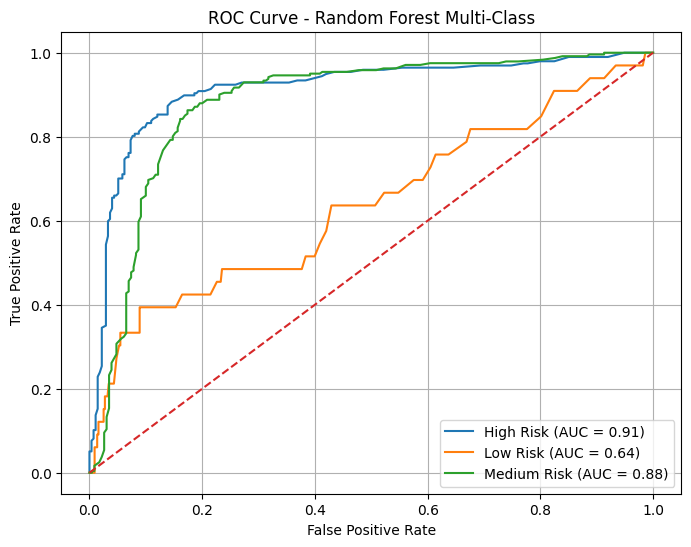

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = ["High Risk", "Low Risk", "Medium Risk"]

y_test_bin = label_binarize(
    y_test,
    classes=classes
)


y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Multi-Class")

plt.legend()
plt.grid()

plt.show()

In [19]:

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                     Feature  Importance
4            savings_balance    0.143403
3                loan_amount    0.125844
9          disposable_income    0.116706
8               total_income    0.100711
2                   expenses    0.096891
0             monthly_income    0.094687
6          repayment_history    0.085599
5             existing_loans    0.082301
1               other_income    0.064860
7    guarantor_support_count    0.037545
22     loan_type_above 25000    0.011920
10     loan_type_Above_25000    0.010659
11     loan_type_Below_25000    0.006059
34            loan_type_self    0.004035
31  loan_type_lifestyle loan    0.003678


In [20]:
rf_accuracy = accuracy_score(y_test, y_pred)
lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        rf_accuracy,
        lr_accuracy,
        dt_accuracy
    ]
})

print(comparison)

                 Model  Accuracy
0        Random Forest  0.804671
1  Logistic Regression  0.670913
2        Decision Tree  0.726115


In [21]:
import joblib

joblib.dump(model, "combined_risk_prediction_model.pkl")
joblib.dump(X.columns.tolist(), "combined_model_columns.pkl")

print("Combined model saved successfully")

Combined model saved successfully


# decision Recommendation

In [22]:
loan_products = {
    "personal_consumer": {"min": 0, "max": 25000, "interest_rate": 20, "max_months": 60},
    "long_term": {"min": 0, "max": 250000, "interest_rate": 17, "max_months": 60},
    "below_25000": {"min": 0, "max": 25000, "interest_rate": 8, "max_months": 60},
    "above_25000": {"min": 25000, "max": 150000, "interest_rate": 8, "max_months": 60},
    "lifestyle": {"min": 50000, "max": 500000, "interest_rate": 14, "max_months": 60},
    "sampatha": {"min": 100000, "max": 100000, "interest_rate": 15, "max_months": 60},
    "self_development": {"min": 0, "max": 100000, "interest_rate": 14, "max_months": 60},
    "lakjaya": {"min": 100000, "max": 1000000, "interest_rate": 15, "max_months": 60}
}

In [23]:
def decision_recommendation(
    risk_level,
    monthly_income,
    expenses,
    requested_loan_amount,
    selected_loan_type
):
    product = loan_products[selected_loan_type]

    min_amount = product["min"]
    max_amount = product["max"]
    interest_rate = product["interest_rate"]
    max_months = product["max_months"]

    disposable_income = monthly_income - expenses

    if disposable_income <= 0:
        return {
            "predicted_risk_level": risk_level,
            "selected_loan_type": selected_loan_type,
            "interest_rate": interest_rate,
            "final_decision": "Reject - insufficient disposable income",
            "requested_loan_amount": float(requested_loan_amount),
            "recommended_loan_amount": 0.0,
            "suggested_monthly_installment": 0.0,
            "estimated_repayment_duration_months": 0,
            "loan_type_min_limit": min_amount,
            "loan_type_max_limit": max_amount
        }

    safe_installment = max(disposable_income * 0.35, 0)

    if risk_level == "Low Risk":
        risk_factor = 1.0
    elif risk_level == "Medium Risk":
        risk_factor = 0.75
    else:
        risk_factor = 0.5

    affordable_loan_amount = safe_installment * max_months * risk_factor

    recommended_loan = min(
        requested_loan_amount,
        max_amount,
        affordable_loan_amount
    )

    if recommended_loan < min_amount or safe_installment <= 0:
        final_decision = "Not suitable for selected loan type"
        recommended_loan = 0
        suggested_monthly_installment = 0
        estimated_months = 0

    else:
        if recommended_loan >= requested_loan_amount:
            final_decision = "Approve"
        elif risk_level == "High Risk":
            final_decision = "Request guarantor or reduce amount"
        else:
            final_decision = "Approve with reduced amount"

        suggested_monthly_installment = safe_installment

        estimated_months = (
            recommended_loan / suggested_monthly_installment
            if suggested_monthly_installment > 0 else 0
        )

        if estimated_months > max_months:
            estimated_months = max_months

    return {
        "predicted_risk_level": risk_level,
        "selected_loan_type": selected_loan_type,
        "interest_rate": interest_rate,
        "final_decision": final_decision,
        "requested_loan_amount": float(requested_loan_amount),
        "recommended_loan_amount": float(round(recommended_loan, 2)),
        "suggested_monthly_installment": float(round(suggested_monthly_installment, 2)),
        "estimated_repayment_duration_months": int(round(estimated_months)),
        "loan_type_min_limit": min_amount,
        "loan_type_max_limit": max_amount
    }

# Test prediction +Recommendation

In [24]:
sample_customer = X.iloc[[0]]

prediction = model.predict(sample_customer)[0]

print("Predicted Risk Level:", prediction)

customer = combined_df.iloc[0]

result = decision_recommendation(
    risk_level=prediction,
    monthly_income=customer["monthly_income"],
    expenses=customer["expenses"],
    requested_loan_amount=customer["loan_amount"],
    selected_loan_type="long_term"
)

print("\nDecision Recommendation:")
print(result)

Predicted Risk Level: Medium Risk

Decision Recommendation:
{'predicted_risk_level': 'Medium Risk', 'selected_loan_type': 'long_term', 'interest_rate': 17, 'final_decision': 'Approve', 'requested_loan_amount': 86608.98, 'recommended_loan_amount': 86608.98, 'suggested_monthly_installment': 5101.2, 'estimated_repayment_duration_months': 17, 'loan_type_min_limit': 0, 'loan_type_max_limit': 250000}


In [25]:
import sys
import sklearn
import numpy

print(sys.executable)
print(sklearn.__version__)
print(numpy.__version__)

C:\Users\DENETH\.conda\envs\ga_env\python.exe
1.7.2
2.2.6
